In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/dataset/animal_dataset.zip" -d "/content/dataset"


Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/cheetah-resize-224/resize-224/00000236_224resized.png  
  inflating: /content/dataset/cheetah-resize-224/resize-224/00000239_224resized.png  
  inflating: /content/dataset/cheetah-resize-224/resize-224/00000240_224resized.png  
  inflating: /content/dataset/cheetah-resize-224/resize-224/00000242_224resized.png  
  inflating: /content/dataset/cheetah-resize-224/resize-224/00000244_224resized.png  
  inflating: /content/dataset/cheetah-resize-224/resize-224/00000245_224resized.png  
  inflating: /content/dataset/cheetah-resize-224/resize-224/00000246_224resized.png  
  inflating: /content/dataset/cheetah-resize-224/resize-224/00000247_224resized.png  
  inflating: /content/dataset/cheetah-resize-224/resize-224/00000248_224resized.png  
  inflating: /content/dataset/cheetah-resize-224/resize-224/00000250_224resized.png  
  inflating: /content/dataset/cheetah-resize-224/resize-224/00000251_224resized.png  
  i

In [ ]:
import os
os.listdir("/content/dataset")


['hyena-resize-512',
 'fox-resize-300',
 'hyena-resize-224',
 'fox-resize-512',
 'wolf-resize-224',
 'tiger-resize-300',
 'wolf-resize-300',
 'cheetah-resize-512',
 'tiger-resize-512',
 'lion-resize-300',
 'hyena-resize-300',
 'lion-resize-224',
 'tiger-resize-224',
 'wolf-resize-512',
 'cheetah-resize-224',
 'lion-resize-512',
 'cheetah-resize-300',
 'fox-resize-224']

In [ ]:
import os
import cv2
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
DATASET_PATH = "/content/dataset"
IMG_SIZE = 128

In [ ]:
images = []
labels = []

label_map = {}
current_label = 0

In [ ]:
for root, dirs, files in os.walk(DATASET_PATH):

    for file in files:

        if file.lower().endswith(tuple([".png", ".jpg", ".jpeg"])): # Use tuple for suffixes

            img_path = os.path.join(root,file)

            img = cv2.imread(img_path)
            if img is not None: # Check if image loaded successfully
                img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
                img = img/255.0

                # Extract label from the root directory name
                # Assuming directory structure like /content/dataset/animal-resize-XXX/resize-XXX
                # We want 'animal'
                parts = root.split(os.sep)
                animal_name_with_size = [p for p in parts if 'resize' in p and 'dataset' not in p]

                if animal_name_with_size:
                    animal_name_raw = animal_name_with_size[0].split('-resize')[0]

                    if animal_name_raw not in label_map:
                        label_map[animal_name_raw] = current_label
                        current_label += 1

                    images.append(img)
                    labels.append(label_map[animal_name_raw])
                else:
                    print(f"Could not determine label for {img_path}")
            else:
                print(f"Warning: Could not load image {img_path}")

In [ ]:
X = np.array(images)
y = np.array(labels)

print("Total images:",len(X))
print("Classes:",label_map)

Total images: 5169
Classes: {'hyena': 0, 'fox': 1, 'wolf': 2, 'tiger': 3, 'cheetah': 4, 'lion': 5}


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE,IMG_SIZE,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

cnn_model = Model(inputs=base_model.input, outputs=x)

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
print("Extracting CNN features...")

train_features = cnn_model.predict(X_train)
test_features = cnn_model.predict(X_test)

print("Feature shape:",train_features.shape)

Extracting CNN features...
130/130 ━━━━━━━━━━━━━━━━━━━━ 53s 398ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 13s 393ms/step
Feature shape: (4135, 1280)


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(train_features,y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
y_pred = rf_model.predict(test_features)

In [ ]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy:",accuracy)

Accuracy: 0.9922630560928434


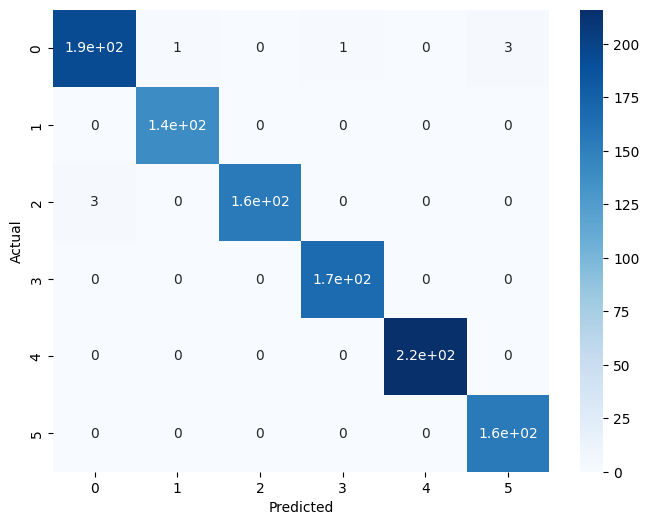

In [ ]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm,annot=True,cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       199
           1       0.99      1.00      1.00       139
           2       1.00      0.98      0.99       158
           3       0.99      1.00      1.00       167
           4       1.00      1.00      1.00       216
           5       0.98      1.00      0.99       155

    accuracy                           0.99      1034
   macro avg       0.99      0.99      0.99      1034
weighted avg       0.99      0.99      0.99      1034

